In [27]:
#import statements
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [55]:
#importing the dataset file
survey_df = pd.read_csv(r"C:\Users\Andrew\Desktop\The Frontier Institute - Programs\Data Science Program Stuff\survey_results_public.csv")

In [4]:
#viewing the data, and unique values for the Age column
survey_df.head()
survey_df["Age"].unique()

<StringArray>
['Under 18 years old',    '35-44 years old',    '45-54 years old',
    '18-24 years old',    '25-34 years old',    '55-64 years old',
  'Prefer not to say',  '65 years or older']
Length: 8, dtype: str

In [5]:
print(survey_df.columns.tolist())

['ResponseId', 'MainBranch', 'Age', 'Employment', 'RemoteWork', 'Check', 'CodingActivities', 'EdLevel', 'LearnCode', 'LearnCodeOnline', 'TechDoc', 'YearsCode', 'YearsCodePro', 'DevType', 'OrgSize', 'PurchaseInfluence', 'BuyNewTool', 'BuildvsBuy', 'TechEndorse', 'Country', 'Currency', 'CompTotal', 'LanguageHaveWorkedWith', 'LanguageWantToWorkWith', 'LanguageAdmired', 'DatabaseHaveWorkedWith', 'DatabaseWantToWorkWith', 'DatabaseAdmired', 'PlatformHaveWorkedWith', 'PlatformWantToWorkWith', 'PlatformAdmired', 'WebframeHaveWorkedWith', 'WebframeWantToWorkWith', 'WebframeAdmired', 'EmbeddedHaveWorkedWith', 'EmbeddedWantToWorkWith', 'EmbeddedAdmired', 'MiscTechHaveWorkedWith', 'MiscTechWantToWorkWith', 'MiscTechAdmired', 'ToolsTechHaveWorkedWith', 'ToolsTechWantToWorkWith', 'ToolsTechAdmired', 'NEWCollabToolsHaveWorkedWith', 'NEWCollabToolsWantToWorkWith', 'NEWCollabToolsAdmired', 'OpSysPersonal use', 'OpSysProfessional use', 'OfficeStackAsyncHaveWorkedWith', 'OfficeStackAsyncWantToWorkWith',

In [6]:
survey_df = survey_df.drop(columns = ['JobSatPoints_1', 'JobSatPoints_4', 'JobSatPoints_5', 'JobSatPoints_6', 'JobSatPoints_7', 'JobSatPoints_8', 'JobSatPoints_9', 
                                      'JobSatPoints_10', 'JobSatPoints_11', 'TimeSearching', 'TimeAnswering', 'SurveyLength', 'SurveyEase', 'Check', 'SOVisitFreq', 'SOAccount',
                                      'SOPartFreq', 'SOHow', 'SOComm', 'NEWSOSites', 'Frequency_1', 'Frequency_2', 'Frequency_3', 'Knowledge_1' , 'Knowledge_2', 'Knowledge_3', 
                                      'Knowledge_4', 'Knowledge_5', 'Knowledge_6', 'Knowledge_7', 'Knowledge_8', 'Knowledge_9'])
survey_df.head(3)

,ResponseId,MainBranch,Age,Employment,RemoteWork,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,TechDoc,...,TBranch,ICorPM,WorkExp,Frustration,ProfessionalTech,ProfessionalCloud,ProfessionalQuestion,Industry,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Hobby,Primary/elementary school,Books / Physical media,NaN,NaN,...,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,API document(s) and/or SDK document(s);User gu...,...,Yes,Individual contributor,17.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,API document(s) and/or SDK document(s);User gu...,...,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
survey_df['AISearchDevHaveWorkedWith'].unique()
survey_df['YearsCodePro'].unique()
print(survey_df.loc[survey_df["YearsCodePro"].isnull(), "YearsCodePro"])


0        NaN
3        NaN
4        NaN
5        NaN
7        NaN
        ... 
65427    NaN
65429    NaN
65430    NaN
65433    NaN
65436    NaN
Name: YearsCodePro, Length: 13827, dtype: str


In [8]:
#drops all rows with null values in the "YearsCodePro" column
survey_df = survey_df.dropna(subset=['YearsCodePro'])

corrected_years = [] #empty list to store corrected years

#for loop, cycles through "YearsCodePro" column, and replaces string values with rounded integers
for year in survey_df['YearsCodePro']:
   if year == "Less than 1 year":  #rounds "Less than 1 year" to 0 years
        corrected_years.append(0)
   elif year == "More than 50 years":
      corrected_years.append(51)  #rounds "More than 50 years" to 51 years
   else:
       corrected_years.append(int(year))       
survey_df['YearsCodePro'] = corrected_years

survey_df['YearsCodePro'] #test to make sure code worked

1        17
2        27
6         7
9        11
11       25
         ..
65428     7
65431    24
65432     3
65434     5
65435     2
Name: YearsCodePro, Length: 51610, dtype: int64

In [9]:
age_numbers = []

#for loop: cycles through the dataset, and uses conditional to assign a numerical value to age ranges
#Adds the numbers in a list, into a new column, corresponding to each row
for age in survey_df['Age']:
    if age == 'Under 18 years old':
        age_numbers.append(1)      # 1 --> <18
    elif age == '18-24 years old':
        age_numbers.append(2)      # 2 --> 18-24
    elif age == '25-34 years old':
        age_numbers.append(3)      # 3 --> 25-34
    elif age == '35-44 years old':
        age_numbers.append(4)      # 4 --> 35-44
    elif age == '45-54 years old':
        age_numbers.append(5) # 5 --> 45-54
    elif age == '55-64 years old':
        age_numbers.append(6) # 6 --> 55-64
    elif age == '65 years or older':
        age_numbers.append(7) # 7 --> 65+
    else:
        age_numbers.append(-0)    # For 'prefer not to say'

# Put the list back into the dataset
survey_df['AgeCategory'] = age_numbers
survey_df.insert(3, 'AgeCategory', survey_df.pop('AgeCategory')) #Moves the column right beside 'Age', the 3rd index
survey_df.head(3)

,ResponseId,MainBranch,Age,AgeCategory,Employment,RemoteWork,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,TBranch,ICorPM,WorkExp,Frustration,ProfessionalTech,ProfessionalCloud,ProfessionalQuestion,Industry,ConvertedCompYearly,JobSat
1,2,I am a developer by profession,35-44 years old,4,"Employed, full-time",Remote,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,Yes,Individual contributor,17.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,5,"Employed, full-time",Remote,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,7,"I am not primarily a developer, but I write co...",35-44 years old,4,"Employed, full-time",Remote,I don’t code outside of work,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)","Other online resources (e.g., videos, blogs, f...",Technical documentation;Stack Overflow;Written...,...,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


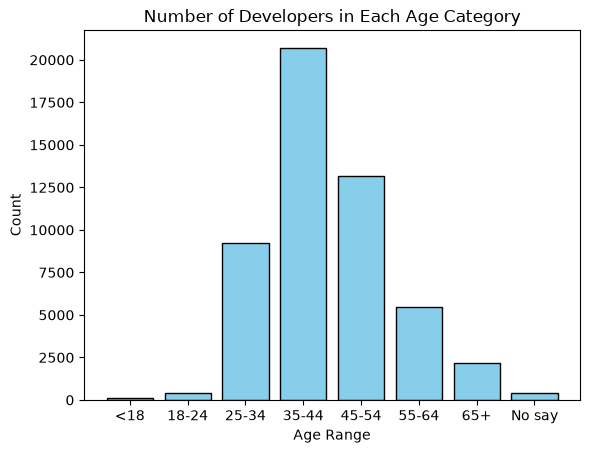

In [10]:
#Gets counts of the age category, sorted from 0-7
age_counts = survey_df['AgeCategory'].value_counts().sort_index()

#plotting bar ,graph, with some color
plt.bar(age_counts.index, age_counts.values, color='skyblue', edgecolor='black')

#using labels to force x axis to read the age ranges, instead of 0-7
labels = ['<18', '18-24', '25-34', '35-44', '45-54', '55-64', '65+', 'No say']
plt.xticks(ticks=age_counts.index[:8], labels=labels)

plt.title("Number of Developers in Each Age Category")
plt.xlabel("Age Range")
plt.ylabel("Count")
plt.show()

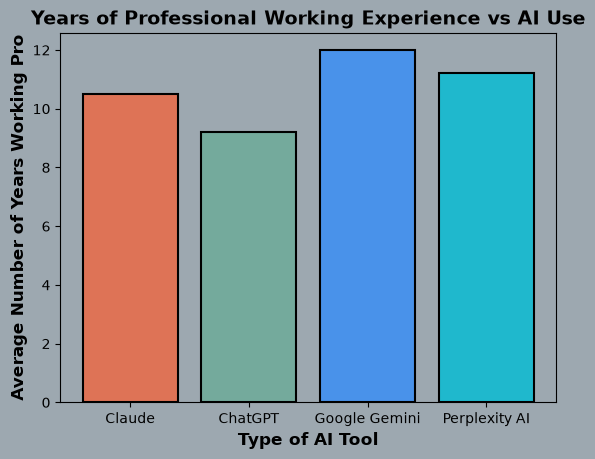

In [21]:
#Purpose of graph: shows that those who use AI tools in general have lengthy amounts of coding experience

#groups survey_df by the type of AI tool used, then gets the 'YearsCodePro" column --> gets the average per group
survey_filtered = survey_df.groupby('AISearchDevHaveWorkedWith')['YearsCodePro'].mean()

#filters to only look for a few types of AI tools in a list
averages = survey_filtered.loc[['Claude', 'ChatGPT', 'Google Gemini', 'Perplexity AI']]

x = averages.index #names of the AI tools
y = averages.values #averages of their years coding professionally
plt.figure(facecolor='#9da8b0')
plt.bar(x, y, color=['#DE7356', '#74AA9C', '#4992ea', '#1FB8CD'], edgecolor='black', linewidth=1.5)


plt.gca().set_facecolor('#9da8b0')


plt.title("Years of Professional Working Experience vs AI Use", fontsize=14, fontweight='bold')
plt.xlabel("Type of AI Tool", fontsize=12, fontweight='bold')
plt.ylabel("Average Number of Years Working Pro", fontsize=12, fontweight='bold',)
plt.show()

In [70]:
unique_values = ['Under 18 years old', '18-24 years old', '25-34 years old', '35-44 years old', '45-54 years old', 
                 '55-64 years old', '65 years or older', 'Prefer not to say']

ai_age = survey_df[["AISearchDevHaveWorkedWith", "Age"]].copy()


In [71]:
ai_age = ai_age.dropna() #drops null values

In [72]:
#Remove Prefer not to say, we don't need this input

ai_age = ai_age[
    ai_age["Age"] != "Prefer not to say"
]


In [73]:
ai_age["AISearchDevHaveWorkedWith"].head(10)

5                   ChatGPT;GitHub Copilot;OpenAI Codex
7                                               ChatGPT
9                                 ChatGPT;Google Gemini
10    ChatGPT;GitHub Copilot;Google Gemini;Meta AI;V...
13                                              ChatGPT
15      ChatGPT;Google Gemini;Visual Studio Intellicode
16     ChatGPT;GitHub Copilot;Visual Studio Intellicode
17                                              ChatGPT
18                               ChatGPT;GitHub Copilot
20                                              ChatGPT
Name: AISearchDevHaveWorkedWith, dtype: str

In [74]:
#Splits the tools in each row
ai_age["AITool"] = (ai_age["AISearchDevHaveWorkedWith"].str.split(";"))



In [77]:
#Puts each AI tool in a separate row, but they still correspond to the same people
ai_age = ai_age.explode("AITool")
ai_age

,AISearchDevHaveWorkedWith,Age,AITool
5,ChatGPT;GitHub Copilot;OpenAI Codex,Under 18 years old,ChatGPT
5,ChatGPT;GitHub Copilot;OpenAI Codex,Under 18 years old,GitHub Copilot
5,ChatGPT;GitHub Copilot;OpenAI Codex,Under 18 years old,OpenAI Codex
7,ChatGPT,18-24 years old,ChatGPT
9,ChatGPT;Google Gemini,35-44 years old,ChatGPT
...,...,...,...
65414,Bing AI;ChatGPT;GitHub Copilot;Google Gemini;V...,18-24 years old,ChatGPT
65414,Bing AI;ChatGPT;GitHub Copilot;Google Gemini;V...,18-24 years old,GitHub Copilot
65414,Bing AI;ChatGPT;GitHub Copilot;Google Gemini;V...,18-24 years old,Google Gemini
65414,Bing AI;ChatGPT;GitHub Copilot;Google Gemini;V...,18-24 years old,Visual Studio Intellicode


In [76]:
#Remove extra spaces from tool names
ai_age["AITool"] = ai_age['AITool'].str.strip()

In [61]:
#Find the eight most commonly reported AI tools
top_tools = (ai_age["AITool"].value_counts().head(8).index)
top_tools

Index(['ChatGPT', 'GitHub Copilot', 'Google Gemini', 'Bing AI',
       'Visual Studio Intellicode', 'Claude', 'Codeium', 'WolframAlpha'],
      dtype='str', name='AITool')

In [62]:
#A new df with the only the top 8 AI tools 
ai_age_top = ai_age[ai_age["AITool"].isin(top_tools)]

#creating a percentage table
age_percent = pd.crosstab(ai_age_top["AITool"], ai_age_top["Age"], normalize = "index") * 100

#pd.crosstab() makes a table that compared AI tool and age group
#nioroomalize caluclates percentrages within each AI tool

#print(ai_age_top.columns[ai_age_top.columns.duplicated()])
#print(ai_age_top.index.is_unique())

ValueError: cannot reindex on an axis with duplicate labels